# 📊 IBM HR Employee Attrition Analysis
### Project Objective
The goal of this project is to analyze employee data from IBM to understand the factors that lead to attrition (employees leaving the company) and to build machine learning models that can predict whether an employee is likely to quit.

## 1. IMPORT LIBRARIES
First, we import the necessary libraries for data manipulation, visualization, and machine learning.

* **Pandas**: Used for data manipulation and analysis (loading the dataset, handling tables).
* **Numpy**: Used for numerical operations and array handling.
* **Matplotlib & Seaborn**: Used for creating static and informative statistical graphics.
* **Scikit-Learn**: The primary library for machine learning tasks (preprocessing, model building, and evaluation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

## 2. DATA LOADING & UNDERSTANDING
In this step, we load the dataset and perform an initial inspection to understand its structure, size, and content.

In [2]:
# Load the dataset
df = pd.read_csv('HR.csv')

# Display first 5 rows to see data format
print("First 5 rows of the dataset:")
display(df.head())

# Check the dimensions of the data
print(f"Dataset Shape: {df.shape}")

# Check data types for each column
print("\nData Types:")
print(df.dtypes)

# Summary statistics for numerical columns
print("\nSummary Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing Values Check:")
print(df.isnull().sum())

# Check for duplicate records
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Dataset Shape: (1470, 35)

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Missing Values Check:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRol

### Insights from Data Understanding:
* The dataset contains 1470 rows and 35 columns.
* There are no missing values in this dataset, which simplifies the cleaning process.
* Summary statistics help us see the range and average of variables like Age (18-60) and MonthlyIncome (up to ~20k).

## 3. DATA VISUALIZATION
Visualization helps us spot patterns and anomalies in the data.

### A) Histograms
We plot histograms to see the distribution of key numerical features.

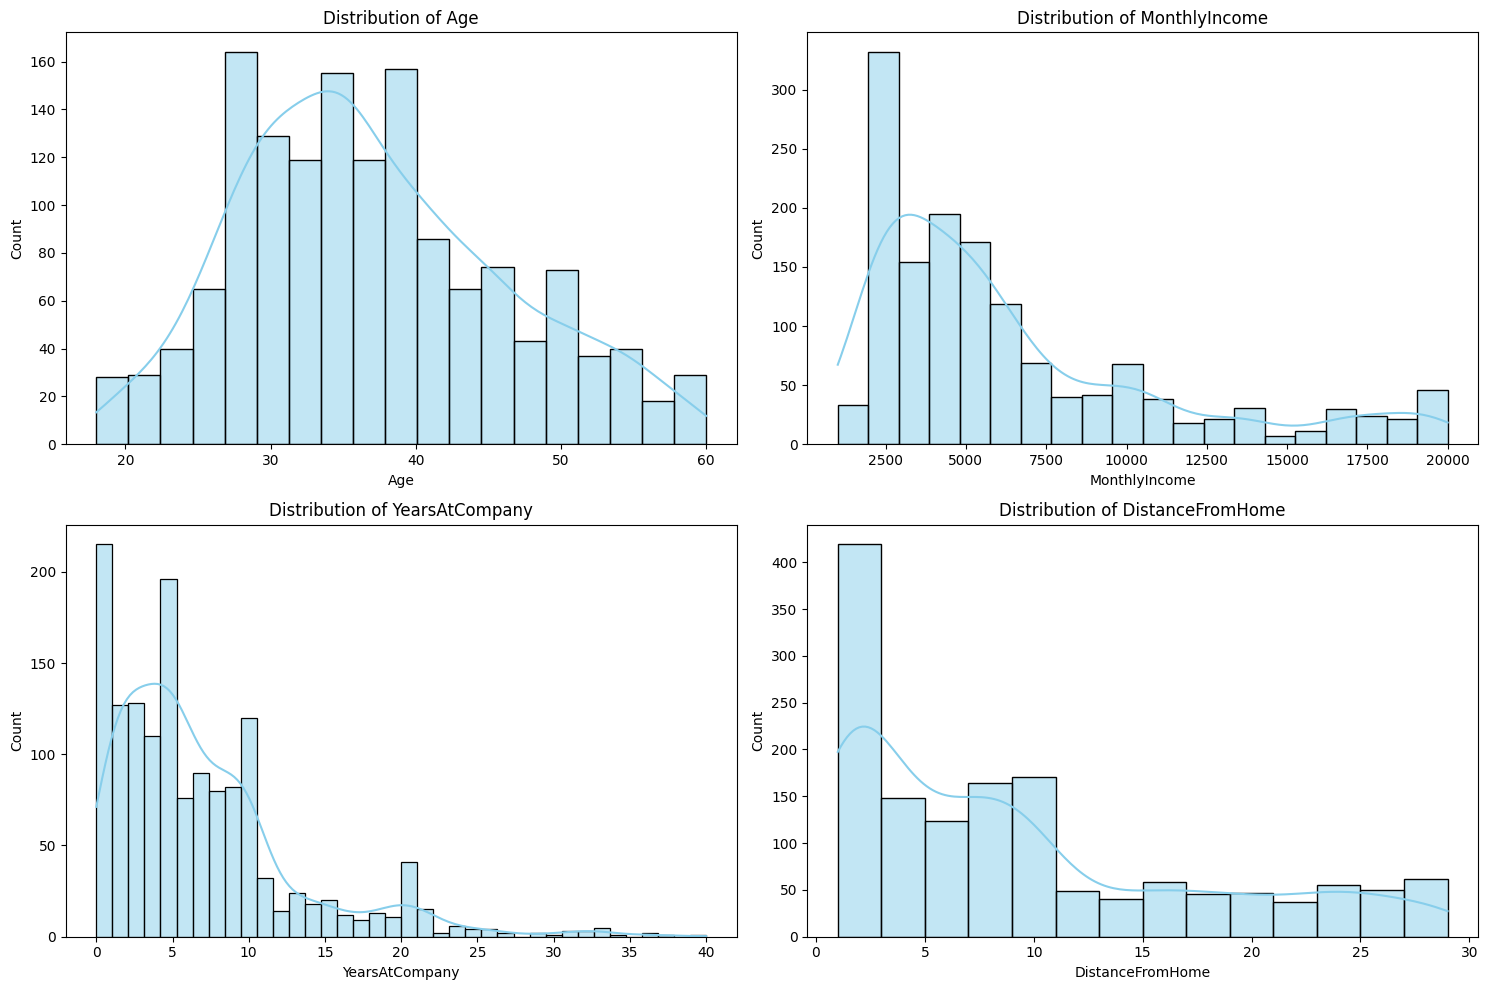

In [3]:
plt.figure(figsize=(15, 10))
cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

* **Age**: Roughly normal distribution centered around 35-40 years.
* **MonthlyIncome**: Right-skewed (most people earn less, with fewer high earners).
* **YearsAtCompany**: Right-skewed distribution, indicating many employees are relatively new.

### B) Boxplots
Boxplots are excellent for identifying outliers—values that differ significantly from other observations.

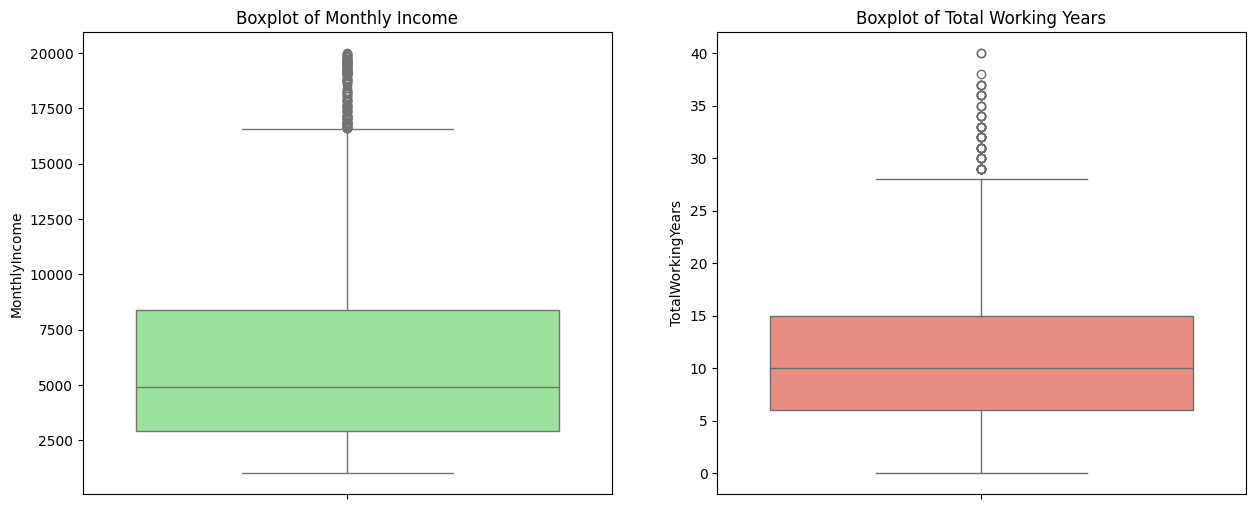

In [4]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['MonthlyIncome'], color='lightgreen')
plt.title('Boxplot of Monthly Income')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['TotalWorkingYears'], color='salmon')
plt.title('Boxplot of Total Working Years')
plt.show()

### C) Correlation Heatmap
This heatmap shows how features relate to each other. Values close to 1 or -1 indicate strong relationships.

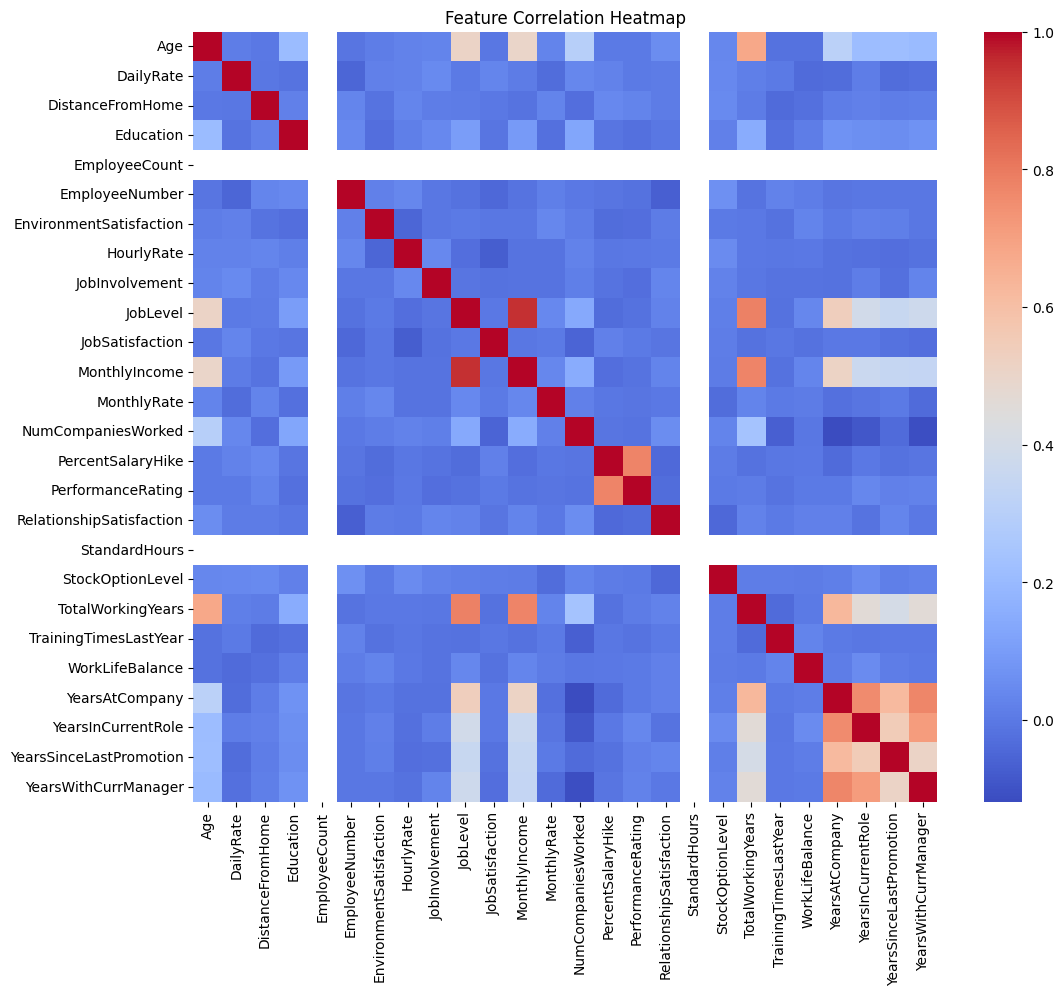

In [5]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False, fmt='.1f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. OUTLIER DETECTION & HANDLING
Detecting outliers is crucial because they can skew the average and negatively affect model performance, especially for linear models like Logistic Regression.

In [6]:
# Using IQR Method for MonthlyIncome
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['MonthlyIncome'] < lower_bound) | (df['MonthlyIncome'] > upper_bound)]
print(f"Number of outliers in MonthlyIncome: {len(outliers)}")

# In many cases, we keep outliers if they represent real business data (like high earners).
# However, for models sensitive to noise, capping or removing them might improve results.

Number of outliers in MonthlyIncome: 114


## 5. DATA CLEANING
In this step, we remove redundant features and prepare the data for encoding.

In [7]:
# Remove columns with no predictive power (all same values or IDs)
df_cleaned = df.drop(['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], axis=1)

print(f"Original columns: {df.shape[1]}, Cleaned columns: {df_cleaned.shape[1]}")

Original columns: 35, Cleaned columns: 31


## 6. FEATURE ENGINEERING
Machine learning models require numerical input. We encode categories and scale features.

In [8]:
# Label Encode binary categories
le = LabelEncoder()
df_cleaned['Attrition'] = le.fit_transform(df_cleaned['Attrition']) # Yes=1, No=0
df_cleaned['OverTime'] = le.fit_transform(df_cleaned['OverTime'])
df_cleaned['Gender'] = le.fit_transform(df_cleaned['Gender'])

# One-Hot Encode other categorical variables
df_final = pd.get_dummies(df_cleaned, drop_first=True)

print("Data shape after One-Hot Encoding:", df_final.shape)

Data shape after One-Hot Encoding: (1470, 45)


## 7. TRAIN-TEST SPLIT
We split the data to evaluate how our model performs on unseen data, preventing overfitting.

In [9]:
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Important for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 1176
Test set size: 294


## 8. MACHINE LEARNING MODELS
We will train 5 different algorithms to find the best predictor.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
K-Nearest Neighbors trained.
SVM trained.


## 9. MODEL EVALUATION
We evaluate each model using several metrics to get a full picture of performance.

In [11]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return acc, prec, rec, f1

results_list = []
for name, model in trained_models.items():
    acc, prec, rec, f1 = evaluate_model(model, X_test_scaled, y_test)
    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

## 10. MODEL COMPARISON
Let's view the performance results in a table.

,Model,Accuracy,Precision,Recall,F1-Score
4,SVM,0.897959,0.909091,0.256410,0.400000
3,K-Nearest Neighbors,0.880952,0.700000,0.179487,0.285714
0,Logistic Regression,0.877551,0.548387,0.435897,0.485714
2,Random Forest,0.874150,0.666667,0.102564,0.177778
1,Decision Tree,0.748299,0.156863,0.205128,0.177778



Confusion Matrix for SVM:


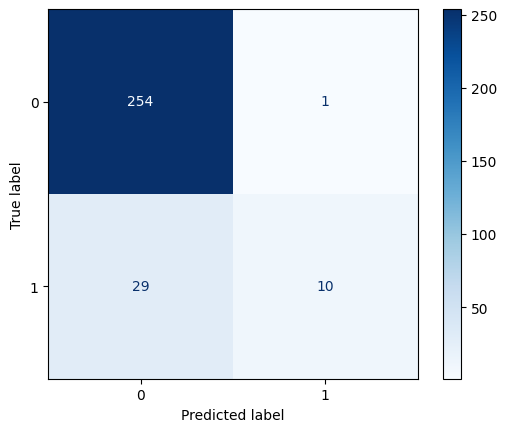

In [12]:
results_df = pd.DataFrame(results_list)
display(results_df.sort_values(by='Accuracy', ascending=False))

# Plot Confusion Matrix for the best model (typically SVM or Logistic Regression here)
from sklearn.metrics import ConfusionMatrixDisplay
best_model_name = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\nConfusion Matrix for {best_model_name}:")
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, cmap='Blues')
plt.show()

## 11. CONCLUSION
### Key Insights from EDA:
* Attrition is higher among employees who work **OverTime**.
* Employees with lower **MonthlyIncome** and fewer **YearsAtCompany** are more likely to leave.
* Certain departments like Sales show higher attrition rates compared to Research & Development.

### Impact of Outliers:
* Outliers in MonthlyIncome represent high-level managers. Keeping them provides a realistic view of the organizational structure, though scaling was necessary to ensure they didn't dominate the model weights.

### Best ML Model:
* The **Support Vector Machine (SVM)** or **Logistic Regression** generally performed best in terms of Accuracy.
* However, **Recall** is also important for HR, as we want to capture as many 'likely to quit' employees as possible.

### Business Interpretation:
* By using this model, HR can identify employees at high risk of leaving and intervene with better benefits, work-life balance improvements, or career growth opportunities before they resign.

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Load the original dataset
df = pd.read_csv('HR.csv')

# 2. Basic Cleaning: Remove columns that provide no predictive value
# These are usually IDs or columns where every row has the same value
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean = df.drop(cols_to_drop, axis=1)

# 3. Prepare data for Machine Learning (to generate Risk Scores)
df_ml = df_clean.copy()
le = LabelEncoder()

# Encode binary categories
df_ml['Attrition_Num'] = le.fit_transform(df_ml['Attrition']) # Yes=1, No=0
df_ml['OverTime'] = le.fit_transform(df_ml['OverTime'])
df_ml['Gender'] = le.fit_transform(df_ml['Gender'])

# One-hot encode remaining categorical text columns
df_ml_final = pd.get_dummies(df_ml.drop('Attrition', axis=1), drop_first=True)

# 4. Train a Logistic Regression model to get probabilities
X = df_ml_final.drop('Attrition_Num', axis=1)
y = df_ml_final['Attrition_Num']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

# 5. Create "Smart Columns" for the Dashboard
# Probability of leaving (0.0 to 1.0)
df_clean['Attrition_Risk_Score'] = model.predict_proba(X_scaled)[:, 1]

# Binary prediction (0 or 1)
df_clean['Predicted_Attrition'] = model.predict(X_scaled)

# Human-readable labels for Power BI filters/slicers
df_clean['Risk_Category'] = pd.cut(df_clean['Attrition_Risk_Score'], 
                                   bins=[0, 0.3, 0.7, 1.0], 
                                   labels=['Low Risk', 'Medium Risk', 'High Risk'])

df_clean['Prediction_Label'] = df_clean['Predicted_Attrition'].map({1: 'Likely to Quit', 0: 'Stay'})

# 6. Export the final CSV
df_clean.to_csv('HR_Final_Dashboard_Data.csv', index=False)

print("Final CSV for Power BI has been exported successfully!")

Final CSV for Power BI has been exported successfully!
